# Naive Generative Model — Swiss Roll Distribution



## 1. Imports & Setup

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Swiss Roll Dataset

The Swiss Roll is a classic 2D dataset with a spiral structure

In [48]:
def swissRoll(samples=1024, noise=0.5):
    """Generate a 2D Swiss Roll distribution (from the lecture slides)."""
    t = 1.5 * 3.14 * (1 + 2 * tf.random.uniform((samples, 1)))
    x = t * tf.math.cos(t)
    y = t * tf.math.sin(t)
    X = tf.concat([x, y], axis=1)
    if noise > 0:
        X += noise * tf.random.normal(shape=(samples, 2))
    return X


# Generate a large sample to visualise the target distribution
target_samples = swissRoll(samples=4096, noise=0.5).numpy()



## 3. Source Distribution

The source distribution is a **standard 2D Gaussian** $\mathcal{N}(0, I)$.

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12266/958915654.py:11: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('Source Distribution — $\mathcal{N}(0, I)$', fontsize=13)


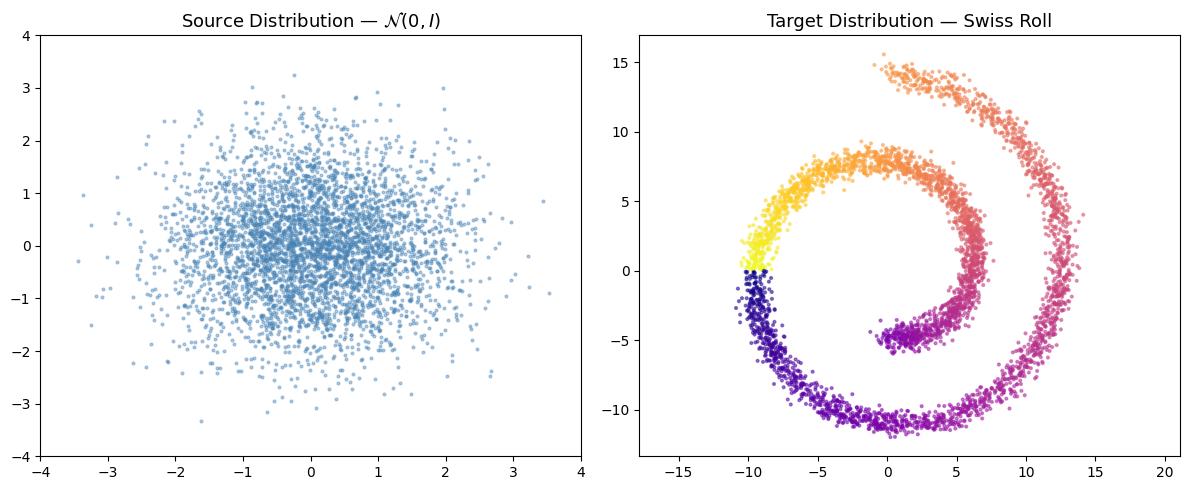

In [49]:
def sample_source(batch_size=1024):
    """Sample from a standard 2D Gaussian (source distribution)."""
    return tf.random.normal(shape=(batch_size, 2))


source_samples = sample_source(4096).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(source_samples[:, 0], source_samples[:, 1],
                s=4, alpha=0.4, color='steelblue')
axes[0].set_title('Source Distribution — $\mathcal{N}(0, I)$', fontsize=13)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)

axes[1].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.5, c=np.arctan2(target_samples[:, 1], target_samples[:, 0]),
                cmap='plasma')
axes[1].set_title('Target Distribution — Swiss Roll', fontsize=13)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

## 4. Naive Model Architecture


```
2 → Dense(64) → BatchNorm → ReLU → ... (4 blocks) → 2
```

- Input: 2D source sample
- Output: 2D predicted target point
- Loss: **MSE**
- ~16k parameters

In [50]:
def build_naive_model(hidden_dim=64, n_blocks=4):
    """Naive generative model: Dense → BatchNorm → ReLU blocks."""
    inputs = keras.Input(shape=(2,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    outputs = layers.Dense(2)(x)   # linear output — raw 2D coordinates
    return keras.Model(inputs, outputs, name='naive_model')


model = build_naive_model()
model.summary()

Model: "naive_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,826 (54.01 KB)

 Trainable params: 13,314 (52.01 KB)

 Non-trainable params: 512 (2.00 KB)

## 5. Training Loop

Hyperparameters
- Batch size: **1024**
- Steps: **1000**
- Optimizer: **Adam** with lr = 1e-3

### What my loop do
1. Sample a point from the target distribution
2. Sample a point from the source distribution
3. Feed the source point to the model
4. Compare model output to the target point using MSE
5. Update parameters



In [51]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
mse_loss  = keras.losses.MeanSquaredError()

BATCH_SIZE = 1024
STEPS      = 1000

loss_history = []

for step in range(STEPS):
    # --- Step 1 & 2: sample from both distributions ---
    target = swissRoll(samples=BATCH_SIZE, noise=0.5)          # target samples
    source = sample_source(BATCH_SIZE)                          # source samples (model input)

    # --- Steps 3-5: forward pass, loss, update ---
    with tf.GradientTape() as tape:
        prediction = model(source, training=True)
        loss = mse_loss(target, prediction)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(loss.numpy())

    if step % 100 == 0:
        print(f'Step {step:4d} / {STEPS}  |  MSE Loss: {loss.numpy():.4f}')

print('\nTraining complete!')

Step    0 / 1000  |  MSE Loss: 50.7411
Step  100 / 1000  |  MSE Loss: 47.8338
Step  200 / 1000  |  MSE Loss: 47.6651
Step  300 / 1000  |  MSE Loss: 45.4847
Step  400 / 1000  |  MSE Loss: 46.2241
Step  500 / 1000  |  MSE Loss: 45.1866
Step  600 / 1000  |  MSE Loss: 46.3086
Step  700 / 1000  |  MSE Loss: 46.4914
Step  800 / 1000  |  MSE Loss: 44.5688
Step  900 / 1000  |  MSE Loss: 47.9278

Training complete!


## 6. Training Curve

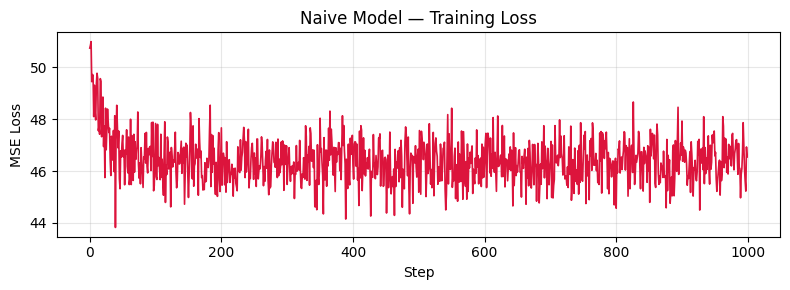

In [52]:
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='crimson', linewidth=1.2)
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.title('Naive Model — Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Generated Samples vs. Target Distribution

now generate samples by feeding fresh Gaussian noise into the model and observe what it produces.

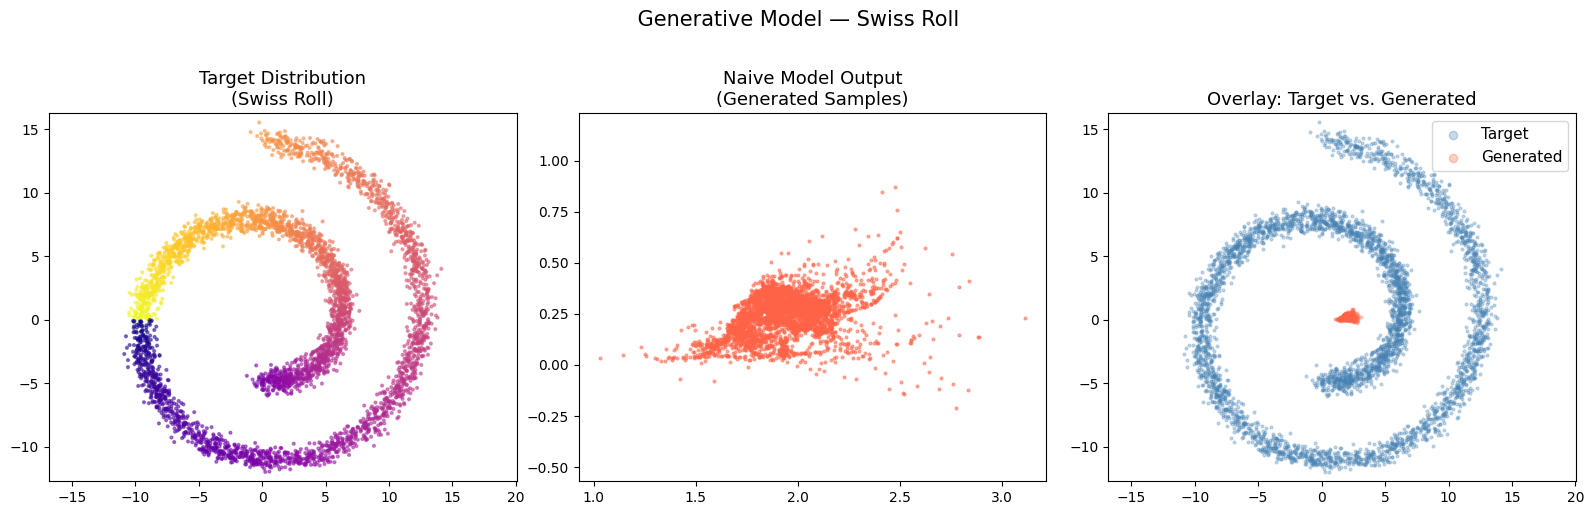

In [53]:
N_GEN = 4096
z = sample_source(N_GEN)                        # fresh source samples
generated = model(z, training=False).numpy()    # model predictions

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground-truth target
axes[0].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.5,
                c=np.arctan2(target_samples[:, 1], target_samples[:, 0]),
                cmap='plasma')
axes[0].set_title('Target Distribution\n(Swiss Roll)', fontsize=13)
axes[0].axis('equal')

# Generated samples
axes[1].scatter(generated[:, 0], generated[:, 1],
                s=4, alpha=0.5, color='tomato')
axes[1].set_title('Naive Model Output\n(Generated Samples)', fontsize=13)
axes[1].axis('equal')

# Overlay for comparison
axes[2].scatter(target_samples[:N_GEN, 0], target_samples[:N_GEN, 1],
                s=4, alpha=0.3, color='steelblue', label='Target')
axes[2].scatter(generated[:, 0], generated[:, 1],
                s=4, alpha=0.3, color='tomato', label='Generated')
axes[2].set_title('Overlay: Target vs. Generated', fontsize=13)
axes[2].axis('equal')
axes[2].legend(markerscale=3, fontsize=11)

plt.suptitle(' Generative Model — Swiss Roll', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 8. Analysis — Why Does the Naive Approach Fail?

the naive model collapses to predicting the mean of the distribution.

In [54]:
target_mean = target_samples.mean(axis=0)
generated_mean = generated.mean(axis=0)
generated_std  = generated.std(axis=0)

print('=== Distribution Statistics ===')
print(f'Target mean:       ({target_mean[0]:.3f}, {target_mean[1]:.3f})')
print(f'Generated mean:    ({generated_mean[0]:.3f}, {generated_mean[1]:.3f})')
print(f'Generated std:     ({generated_std[0]:.3f}, {generated_std[1]:.3f})')
print(f'Target std:        ({target_samples.std(axis=0)[0]:.3f}, {target_samples.std(axis=0)[1]:.3f})')
print()



=== Distribution Statistics ===
Target mean:       (1.970, 0.187)
Generated mean:    (1.938, 0.248)
Generated std:     (0.190, 0.102)
Target std:        (6.726, 6.887)



## 9. Summary

| Aspect | Observation |
|--------|-------------|
| **Training loss** | Converges steadily — the model *is* learning something |
| **Generated distribution** | Collapses to a blob near the mean of the Swiss Roll |
| **Root cause** | MSE with unknown target sample → model minimises expected squared error = **predicts the mean** |

### Why this happens

The model receives a source Gaussian sample as input but is compared against a randomly drawn target sample. Since the source and target are sampled independently, the optimal MSE prediction for any input $z$ is:

$$\hat{x}^* = \mathbb{E}[x_{\text{target}}] = \text{mean of Swiss Roll} \approx (0, 0)$$

### What should we do?
VAEs and Reparametrize so the problem becomes well-posed and MSE can be used correctly.


#10. VAE

In [55]:
LATENT_DIM = 2   # same dimensionality as input for easy visualisation

# ── Encoder ──────────────────────────────────────────────────────────────────
def build_encoder(input_dim=2, latent_dim=LATENT_DIM, hidden_dim=64, n_blocks=4):
    """Maps x → (mean, log_var) of q(z|x)."""
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    # Output size is 2×latent_dim: first half = mean, second half = log_var
    latent = layers.Dense(latent_dim * 2)(x)
    return keras.Model(inputs, latent, name='encoder')


# ── Decoder ──────────────────────────────────────────────────────────────────
def build_decoder(latent_dim=LATENT_DIM, output_dim=2, hidden_dim=64, n_blocks=4):
    """Maps z → x̂ (reconstruction of input)."""
    inputs = keras.Input(shape=(latent_dim,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    outputs = layers.Dense(output_dim)(x)
    return keras.Model(inputs, outputs, name='decoder')


encoder = build_encoder()
decoder = build_decoder()

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,956 (54.52 KB)

 Trainable params: 13,444 (52.52 KB)

 Non-trainable params: 512 (2.00 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_29 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_30 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_31 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_32 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,826 (54.01 KB)

 Trainable params: 13,314 (52.01 KB)

 Non-trainable params: 512 (2.00 KB)

In [56]:
def reparametrize(mean, log_var):
    """z = mean + std * epsilon,  epsilon ~ N(0,I)"""
    std = tf.exp(0.5 * log_var)
    epsilon = tf.random.normal(shape=tf.shape(mean))
    return mean + std * epsilon


def kl_divergence(mean, log_var):
    """
    KL( N(mean, std²) || N(0,1) ) per-sample, averaged over batch.
    Closed-form: 0.5 * sum(mean² + exp(log_var) - log_var - 1)
    """
    kl = 0.5 * tf.reduce_sum(
        tf.square(mean) + tf.exp(log_var) - log_var - 1.0,
        axis=1
    )
    return tf.reduce_mean(kl)


def vae_forward(x, training=True):
    latent = encoder(x, training=training)                  # → [B, 2*latent_dim]
    mean    = latent[:, :LATENT_DIM]
    log_var = latent[:, LATENT_DIM:]
    z       = reparametrize(mean, log_var)                  # reparametrization trick
    x_hat   = decoder(z, training=training)                 # reconstruction
    return x_hat, mean, log_var

print('VAE building blocks ready.')

VAE building blocks ready.


In [64]:
optimizer_vae = keras.optimizers.Adam(learning_rate=1e-3)

BETA = 0.1      # weight of KL term (β-VAE style; 1.0 is standard VAE)
BATCH_SIZE = 1024
STEPS = 2000

vae_total_history = []
vae_recon_history = []
vae_kl_history    = []

all_params = encoder.trainable_variables + decoder.trainable_variables

for step in range(STEPS):
    # For the VAE the INPUT and TARGET are the SAME — this is what makes it well-posed!
    x_batch = swissRoll(samples=BATCH_SIZE, noise=0.5)

    with tf.GradientTape() as tape:
        x_hat, mean, log_var = vae_forward(x_batch, training=True)

        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x_batch - x_hat), axis=1))
        kl_loss    = kl_divergence(mean, log_var)
        total_loss = recon_loss + BETA * kl_loss

    grads = tape.gradient(total_loss, all_params)
    optimizer_vae.apply_gradients(zip(grads, all_params))

    vae_total_history.append(total_loss.numpy())
    vae_recon_history.append(recon_loss.numpy())
    vae_kl_history.append(kl_loss.numpy())

    if step % 200 == 0:
        print(f'Step {step:4d}/{STEPS}  |  Total: {total_loss.numpy():.3f}  '
              f'Recon: {recon_loss.numpy():.3f}  KL: {kl_loss.numpy():.3f}')

print('VAE training complete!')

Step    0/2000  |  Total: 1.651  Recon: 0.909  KL: 7.418
Step  200/2000  |  Total: 1.614  Recon: 0.913  KL: 7.011
Step  400/2000  |  Total: 1.272  Recon: 0.562  KL: 7.094
Step  600/2000  |  Total: 1.112  Recon: 0.412  KL: 7.000
Step  800/2000  |  Total: 1.035  Recon: 0.364  KL: 6.716
Step 1000/2000  |  Total: 1.022  Recon: 0.354  KL: 6.671
Step 1200/2000  |  Total: 0.869  Recon: 0.218  KL: 6.508
Step 1400/2000  |  Total: 1.030  Recon: 0.392  KL: 6.379
Step 1600/2000  |  Total: 0.902  Recon: 0.260  KL: 6.425
Step 1800/2000  |  Total: 0.883  Recon: 0.252  KL: 6.318
VAE training complete!


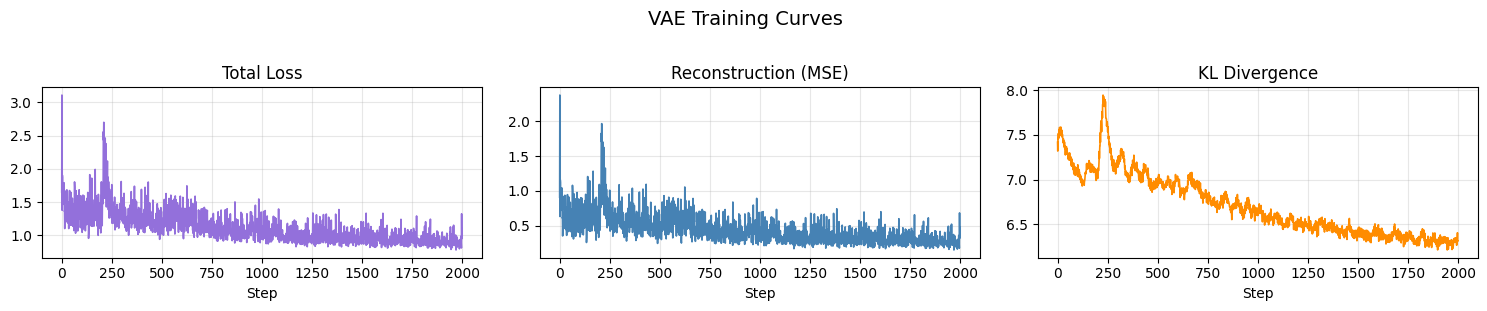

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, hist, label, color in zip(
        axes,
        [vae_total_history, vae_recon_history, vae_kl_history],
        ['Total Loss', 'Reconstruction (MSE)', 'KL Divergence'],
        ['mediumpurple', 'steelblue', 'darkorange']):
    ax.plot(hist, color=color, linewidth=1.2)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Step')
    ax.grid(alpha=0.3)
plt.suptitle('VAE Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#11. LATENT(Z) Space visualization

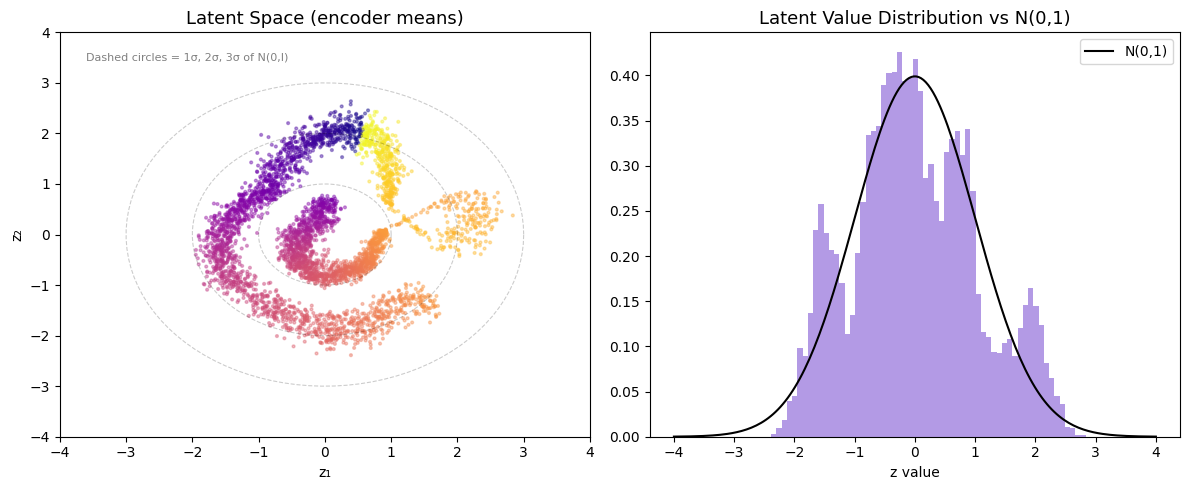

In [66]:
# Encode 4096 Swiss Roll samples to inspect the latent space
x_vis = swissRoll(samples=4096, noise=0.5)
latent_vis = encoder(x_vis, training=False).numpy()
means_vis   = latent_vis[:, :LATENT_DIM]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(means_vis[:, 0], means_vis[:, 1],
                s=4, alpha=0.4,
                c=np.arctan2(x_vis.numpy()[:, 1], x_vis.numpy()[:, 0]),
                cmap='plasma')
axes[0].set_title('Latent Space (encoder means)', fontsize=13)
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)

# Overlay a reference N(0,I) contour
theta = np.linspace(0, 2*np.pi, 100)
for r in [1, 2, 3]:
    axes[0].plot(r*np.cos(theta), r*np.sin(theta), 'k--', alpha=0.2, linewidth=0.8)
axes[0].text(0.05, 0.95, 'Dashed circles = 1σ, 2σ, 3σ of N(0,I)',
             transform=axes[0].transAxes, fontsize=8, va='top', color='gray')

# Histogram of latent values
axes[1].hist(means_vis.flatten(), bins=60, color='mediumpurple', alpha=0.7, density=True)
z_range = np.linspace(-4, 4, 200)
axes[1].plot(z_range, np.exp(-0.5*z_range**2)/np.sqrt(2*np.pi), 'k-', linewidth=1.5, label='N(0,1)')
axes[1].set_title('Latent Value Distribution vs N(0,1)', fontsize=13)
axes[1].legend()
axes[1].set_xlabel('z value')

plt.tight_layout()
plt.show()

#12. discard encoder, use only decoder

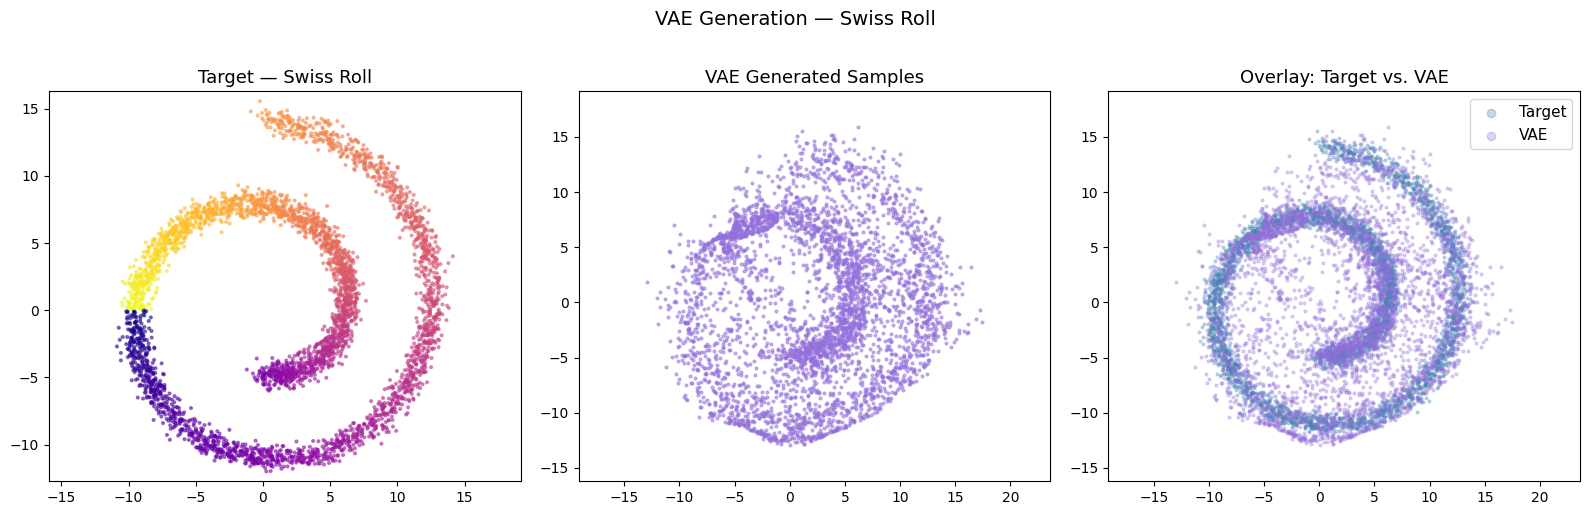

Target std:      [6.726 6.887]
VAE gen std:     [6.032 6.658]


In [67]:
N_GEN = 4096
z_sample = tf.random.normal(shape=(N_GEN, LATENT_DIM))   # sample from prior
vae_generated = decoder(z_sample, training=False).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.5, c=np.arctan2(target_samples[:, 1], target_samples[:, 0]), cmap='plasma')
axes[0].set_title('Target — Swiss Roll', fontsize=13)
axes[0].axis('equal')

axes[1].scatter(vae_generated[:, 0], vae_generated[:, 1],
                s=4, alpha=0.5, color='mediumpurple')
axes[1].set_title('VAE Generated Samples', fontsize=13)
axes[1].axis('equal')

axes[2].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.3, color='steelblue', label='Target')
axes[2].scatter(vae_generated[:, 0], vae_generated[:, 1],
                s=4, alpha=0.3, color='mediumpurple', label='VAE')
axes[2].set_title('Overlay: Target vs. VAE', fontsize=13)
axes[2].axis('equal')
axes[2].legend(markerscale=3, fontsize=11)

plt.suptitle('VAE Generation — Swiss Roll', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Target std:      {target_samples.std(axis=0).round(3)}')
print(f'VAE gen std:     {vae_generated.std(axis=0).round(3)}')

---
# Part C — Generative Adversarial Network (GAN)

## Why GAN?

From the lecture slides:
- **Naive**: MSE with an independent target sample → model collapses to the mean
- **VAE**: Reparametrization makes MSE well-posed, but the KL constraint blurs the latent space
- **GAN**: Use a second network (the **Discriminator**) as the loss function — it *learns* to reward realistic samples

### Architecture
```
z ~ N(0,I)  →  Generator  →  fake sample  ─┐
                                             ├→  Discriminator  →  score
              real sample  ─────────────────┘
```

### Hinge Loss (Slide 10 & 12)

| Network | Loss | Goal |
|---------|------|------|
| **Discriminator** | `RELU(1 − x_real) + RELU(1 + x_fake)` | Push real→+1, fake→−1 |
| **Generator** | `RELU(1 − x_fake)` | Push fake→+1 (fool discriminator) |

### Rules (Slide 12)
- G loss must **not** update D weights, and vice versa
- One step for G, one step for D


## 1. Hinge Loss Functions Visualised

## 2. Build Generator & Discriminator

Generator: same block style as the Naive model (`Dense → BN → ReLU`)

Discriminator: same depth, but uses `LeakyReLU` and a **linear** output (required for Hinge loss)


In [69]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

LATENT_DIM = 2

def build_generator(latent_dim=LATENT_DIM, hidden_dim=64, n_blocks=4):
    """z → [Dense→BN→ReLU]*n → 2D sample"""
    inputs = keras.Input(shape=(latent_dim,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    outputs = layers.Dense(2)(x)
    return keras.Model(inputs, outputs, name='generator')


def build_discriminator(hidden_dim=64, n_blocks=4):
    """2D input → [Dense→LeakyReLU]*n → scalar score (linear, no sigmoid)"""
    inputs = keras.Input(shape=(2,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.LeakyReLU(0.2)(x)
    outputs = layers.Dense(1)(x)   # linear — required for hinge
    return keras.Model(inputs, outputs, name='discriminator')


generator     = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_37 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_38 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_39 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_40 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,826 (54.01 KB)

 Trainable params: 13,314 (52.01 KB)

 Non-trainable params: 512 (2.00 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,737 (49.75 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training Loop

One step D, one step G — gradients are **strictly separated** (separate tapes, separate optimisers).


In [80]:
opt_G = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
opt_D = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

BETA = 0.1      # weight of KL term (β-VAE style; 1.0 is standard VAE)
BATCH_SIZE = 1024
STEPS = 2000

g_loss_history = []
d_loss_history = []

for step in range(STEPS):

    # ── Discriminator step ──────────────────────────────────────────────────
    real = swissRoll(samples=BATCH_SIZE, noise=0.5)
    z    = tf.random.normal((BATCH_SIZE, LATENT_DIM))

    with tf.GradientTape() as tape:
        fake   = generator(z, training=False)           # G is FROZEN here
        d_real = discriminator(real, training=True)
        d_fake = discriminator(fake, training=True)
        # Hinge: RELU(1 - x_real) + RELU(1 + x_fake)
        loss_D = tf.reduce_mean(tf.nn.relu(1.0 - d_real)) + \
                 tf.reduce_mean(tf.nn.relu(1.0 + d_fake))

    grads = tape.gradient(loss_D, discriminator.trainable_variables)
    opt_D.apply_gradients(zip(grads, discriminator.trainable_variables))

    # ── Generator step ──────────────────────────────────────────────────────
    z = tf.random.normal((BATCH_SIZE, LATENT_DIM))

    with tf.GradientTape() as tape:
        fake   = generator(z, training=True)
        d_fake = discriminator(fake, training=False)    # D is FROZEN here
        # Hinge: RELU(1 - x_fake)  — G wants D to output +1
        loss_G = tf.reduce_mean(tf.nn.relu(1.0 - d_fake))

    grads = tape.gradient(loss_G, generator.trainable_variables)
    opt_G.apply_gradients(zip(grads, generator.trainable_variables))

    g_loss_history.append(float(loss_G))
    d_loss_history.append(float(loss_D))

    if step % 100 == 0:
        print(f'Step {step:4d} / {STEPS}  |  D Loss: {float(loss_D):.4f}  G Loss: {float(loss_G):.4f}')

print('\nTraining complete!')


Step    0 / 2000  |  D Loss: 1.9946  G Loss: 0.9279
Step  100 / 2000  |  D Loss: 1.9400  G Loss: 1.0718
Step  200 / 2000  |  D Loss: 1.9238  G Loss: 0.8708
Step  300 / 2000  |  D Loss: 1.8710  G Loss: 1.2374
Step  400 / 2000  |  D Loss: 1.9982  G Loss: 1.2217
Step  500 / 2000  |  D Loss: 1.9435  G Loss: 0.8676
Step  600 / 2000  |  D Loss: 1.9295  G Loss: 0.7095
Step  700 / 2000  |  D Loss: 1.7733  G Loss: 0.9418
Step  800 / 2000  |  D Loss: 1.7470  G Loss: 0.9243
Step  900 / 2000  |  D Loss: 1.8475  G Loss: 0.8463
Step 1000 / 2000  |  D Loss: 1.8244  G Loss: 0.9660
Step 1100 / 2000  |  D Loss: 1.8033  G Loss: 0.9948
Step 1200 / 2000  |  D Loss: 1.6841  G Loss: 0.9086
Step 1300 / 2000  |  D Loss: 1.9937  G Loss: 0.9607
Step 1400 / 2000  |  D Loss: 1.8939  G Loss: 0.7733
Step 1500 / 2000  |  D Loss: 1.5170  G Loss: 0.9562
Step 1600 / 2000  |  D Loss: 1.7580  G Loss: 0.9462
Step 1700 / 2000  |  D Loss: 1.9335  G Loss: 0.8205
Step 1800 / 2000  |  D Loss: 1.7544  G Loss: 0.7598
Step 1900 / 

## 4. Loss Curves

Unlike a standard loss, GAN losses oscillate by design — the two networks compete. What matters is that both losses don't diverge.


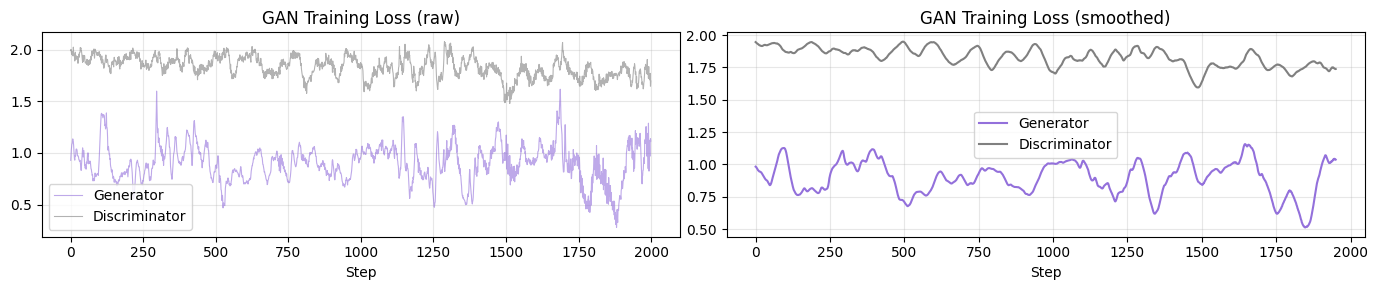

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].plot(g_loss_history, color='mediumpurple', lw=0.8, alpha=0.6, label='Generator')
axes[0].plot(d_loss_history, color='gray',         lw=0.8, alpha=0.6, label='Discriminator')
axes[0].set_title('GAN Training Loss (raw)'); axes[0].set_xlabel('Step')
axes[0].legend(); axes[0].grid(alpha=0.3)

w = 50
axes[1].plot(np.convolve(g_loss_history, np.ones(w)/w, 'valid'), color='mediumpurple', lw=1.5, label='Generator')
axes[1].plot(np.convolve(d_loss_history, np.ones(w)/w, 'valid'), color='gray',         lw=1.5, label='Discriminator')
axes[1].set_title('GAN Training Loss (smoothed)'); axes[1].set_xlabel('Step')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Generated Samples

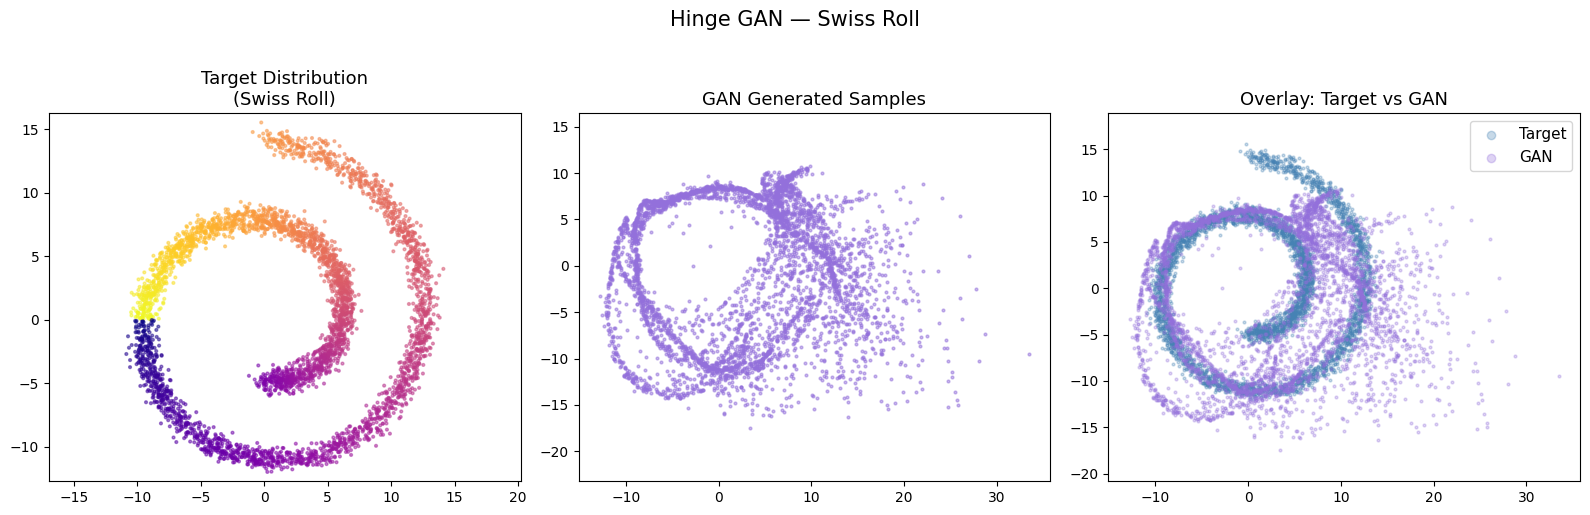

In [82]:
N_GEN = 4096
z = tf.random.normal((N_GEN, LATENT_DIM))
gan_generated = generator(z, training=False).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.5, c=np.arctan2(target_samples[:, 1], target_samples[:, 0]), cmap='plasma')
axes[0].set_title('Target Distribution\n(Swiss Roll)', fontsize=13); axes[0].axis('equal')

axes[1].scatter(gan_generated[:, 0], gan_generated[:, 1], s=4, alpha=0.5, color='mediumpurple')
axes[1].set_title('GAN Generated Samples', fontsize=13); axes[1].axis('equal')

axes[2].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.3, color='steelblue', label='Target')
axes[2].scatter(gan_generated[:, 0],  gan_generated[:, 1],
                s=4, alpha=0.3, color='mediumpurple', label='GAN')
axes[2].set_title('Overlay: Target vs GAN', fontsize=13); axes[2].axis('equal')
axes[2].legend(markerscale=3, fontsize=11)

plt.suptitle('Hinge GAN — Swiss Roll', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 6. Final Comparison — Naive vs VAE vs GAN

Replicating slide 13.


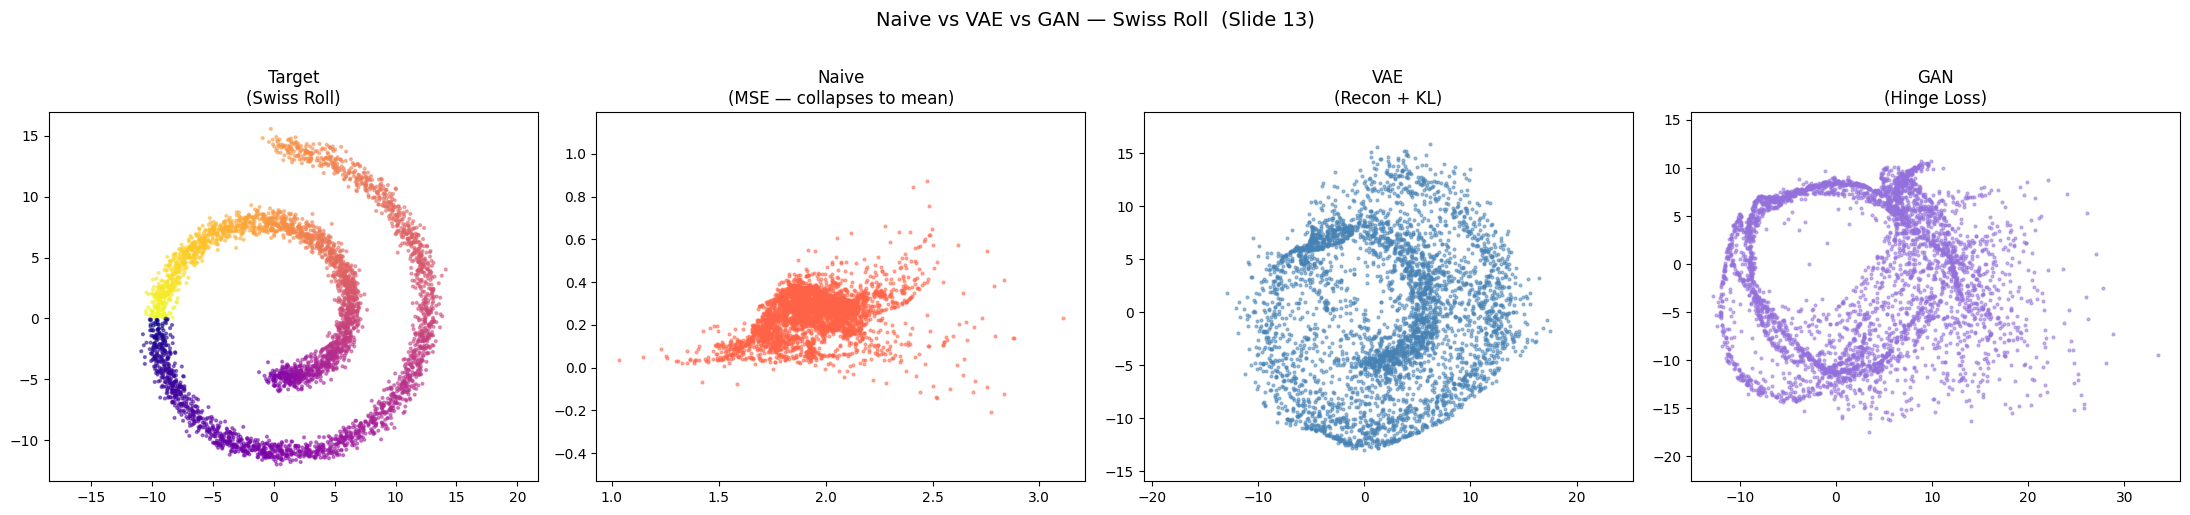

=== Distribution Statistics ===
Target    std=(6.726, 6.887)
Naive     std=(0.190, 0.102)
VAE       std=(6.032, 6.658)
GAN       std=(8.298, 7.257)


In [84]:
# 'generated' = naive output, 'vae_generated' = VAE output (from earlier cells)
# 'gan_generated' = GAN output (just computed)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Target
axes[0].scatter(target_samples[:,0], target_samples[:,1], s=4, alpha=0.5,
                c=np.arctan2(target_samples[:,1], target_samples[:,0]), cmap='plasma')
axes[0].set_title('Target\n(Swiss Roll)', fontsize=12); axes[0].axis('equal')

# Naive
axes[1].scatter(generated[:,0], generated[:,1], s=4, alpha=0.5, color='tomato')
axes[1].set_title('Naive\n(MSE — collapses to mean)', fontsize=12); axes[1].axis('equal')

# VAE
axes[2].scatter(vae_generated[:,0], vae_generated[:,1], s=4, alpha=0.5, color='steelblue')
axes[2].set_title('VAE\n(Recon + KL)', fontsize=12); axes[2].axis('equal')

# GAN
axes[3].scatter(gan_generated[:,0], gan_generated[:,1], s=4, alpha=0.5, color='mediumpurple')
axes[3].set_title('GAN\n(Hinge Loss)', fontsize=12); axes[3].axis('equal')

plt.suptitle('Naive vs VAE vs GAN — Swiss Roll  (Slide 13)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('=== Distribution Statistics ===')
for name, arr in [('Target', target_samples), ('Naive', generated), ('VAE', vae_generated), ('GAN', gan_generated)]:
    print(f'{name:8s}  std=({arr[:,0].std():.3f}, {arr[:,1].std():.3f})')


---
# Pre-rendered GAN Results

### Training Loss Curves

### Generated Samples

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)


def swissRoll(samples=1024, noise=0.5):
    t = 1.5 * 3.14 * (1 + 2 * tf.random.uniform((samples, 1)))
    X = tf.concat([t * tf.math.cos(t), t * tf.math.sin(t)], axis=1)
    return X + noise * tf.random.normal(shape=(samples, 2))

target_samples = swissRoll(4096).numpy()

# The noising is done on a circle to keep constant signal power:
#   x_t = cos(t * π/2) * x_0  +  sin(t * π/2) * ε
# where  t ∈ [0, 1],  ε ~ N(0, I)
# At t=0: pure data.  At t=1: pure noise.

def v_forward(x0, t):
    """
    Add noise to x0 at diffusion time t ∈ [0, 1].
    Returns (x_t, noise) where x_t lives on the signal-noise circle.
    """
    t = tf.cast(t, tf.float32)                          # (B, 1)
    alpha = tf.cos(t * np.pi / 2)                       # signal weight
    sigma = tf.sin(t * np.pi / 2)                       # noise weight
    noise = tf.random.normal(shape=tf.shape(x0))
    x_t   = alpha * x0 + sigma * noise
    return x_t, noise

In [86]:
# Input:  [x_t (2D) | t (1D)]  →  3D total
# Output: predicted x_0  (2D)
# Architecture matches prior labs: Dense → BN → ReLU blocks

def build_denoiser(hidden_dim=128, n_blocks=5):
    """
    Conditioned on noisy input x_t and diffusion time t.
    Predicts the clean sample x_0 directly (v-diffusion target).
    """
    inp = keras.Input(shape=(3,))   # [x_t_1, x_t_2, t]
    x   = inp
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    out = layers.Dense(2)(x)        # predicted x_0
    return keras.Model(inp, out, name='denoiser')

model = build_denoiser()
model.summary()

Model: "denoiser"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_41 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_42 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_43 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_44 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_45 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,378 (271.01 KB)

 Trainable params: 68,098 (266.01 KB)

 Non-trainable params: 1,280 (5.00 KB)

In [87]:
# ── Training ───────────────────────────────────────────────────────────────────
# From slide 7:
#   1. Sample x_0 from target distribution
#   2. Sample random t
#   3. Forward step → x_t
#   4. Model predicts x_0 from [x_t, t]
#   5. MSE loss between prediction and true x_0

optimizer    = keras.optimizers.Adam(learning_rate=1e-3)
mse_loss     = keras.losses.MeanSquaredError()

BATCH_SIZE   = 1024
STEPS        = 1000
loss_history = []

for step in range(STEPS):
    # 1. Sample target
    x0 = swissRoll(BATCH_SIZE, noise=0.5)

    # 2. Sample random t ∈ (0, 1)
    t  = tf.random.uniform((BATCH_SIZE, 1))

    # 3. Forward: add noise on the circle
    x_t, _ = v_forward(x0, t)

    # 4 & 5. Predict x_0, compute MSE
    with tf.GradientTape() as tape:
        inp        = tf.concat([x_t, t], axis=1)   # condition on [x_t, t]
        x0_pred    = model(inp, training=True)
        loss       = mse_loss(x0, x0_pred)          # MSE vs true x_0

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(float(loss))
    if step % 200 == 0:
        print(f'Step {step:4d}/{STEPS}  |  MSE: {loss:.4f}')

print('\nTraining complete!')




Step    0/1000  |  MSE: 50.3733
Step  200/1000  |  MSE: 5.9762
Step  400/1000  |  MSE: 5.8805
Step  600/1000  |  MSE: 5.0864
Step  800/1000  |  MSE: 6.7154

Training complete!


In [88]:
# From slide 8:
#   Start from pure noise (t=1), step down to t=0.
#   At each step, model predicts x_0, then re-noise to the next t level:
#
#     x_{t-1} = cos(t_prev * π/2) * x0_pred  +  sin(t_prev * π/2) * ε_t
#
# The slide shows the mixing weights: 0.8/0.2, 0.6/0.4 etc. — these are
# exactly cos/sin of the next timestep.

def generate(model, n_samples=1024, n_steps=20):
    """
    Reverse diffusion: noise → data in n_steps.
    """
    # Start from pure noise at t=1
    x = tf.random.normal((n_samples, 2))

    # Linearly space timesteps from 1 → 0
    timesteps = np.linspace(1.0, 0.0, n_steps + 1)

    for i in range(n_steps):
        t_now  = timesteps[i]
        t_next = timesteps[i + 1]

        t_batch = tf.fill((n_samples, 1), tf.cast(t_now, tf.float32))
        inp     = tf.concat([x, t_batch], axis=1)

        # Model predicts clean x_0
        x0_pred = model(inp, training=False)

        if t_next > 0:
            # Re-noise to next level (still noisy)
            alpha_next = np.cos(t_next * np.pi / 2)
            sigma_next = np.sin(t_next * np.pi / 2)
            noise      = tf.random.normal((n_samples, 2))
            x          = alpha_next * x0_pred + sigma_next * noise
        else:
            # Final step: return clean prediction
            x = x0_pred

    return x.numpy()



In [89]:
# ── Generate with different step counts (Slide 9) ─────────────────────────────
N_GEN  = 2048
steps_to_try = [1, 5, 10, 20, 100]
generated    = {s: generate(model, N_GEN, s) for s in steps_to_try}
print('Generation done for all step counts.')


Generation done for all step counts.


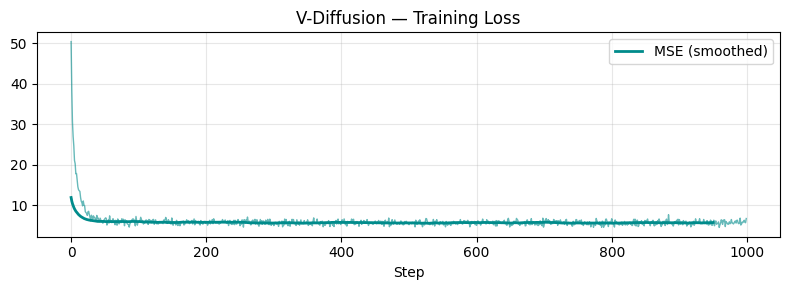

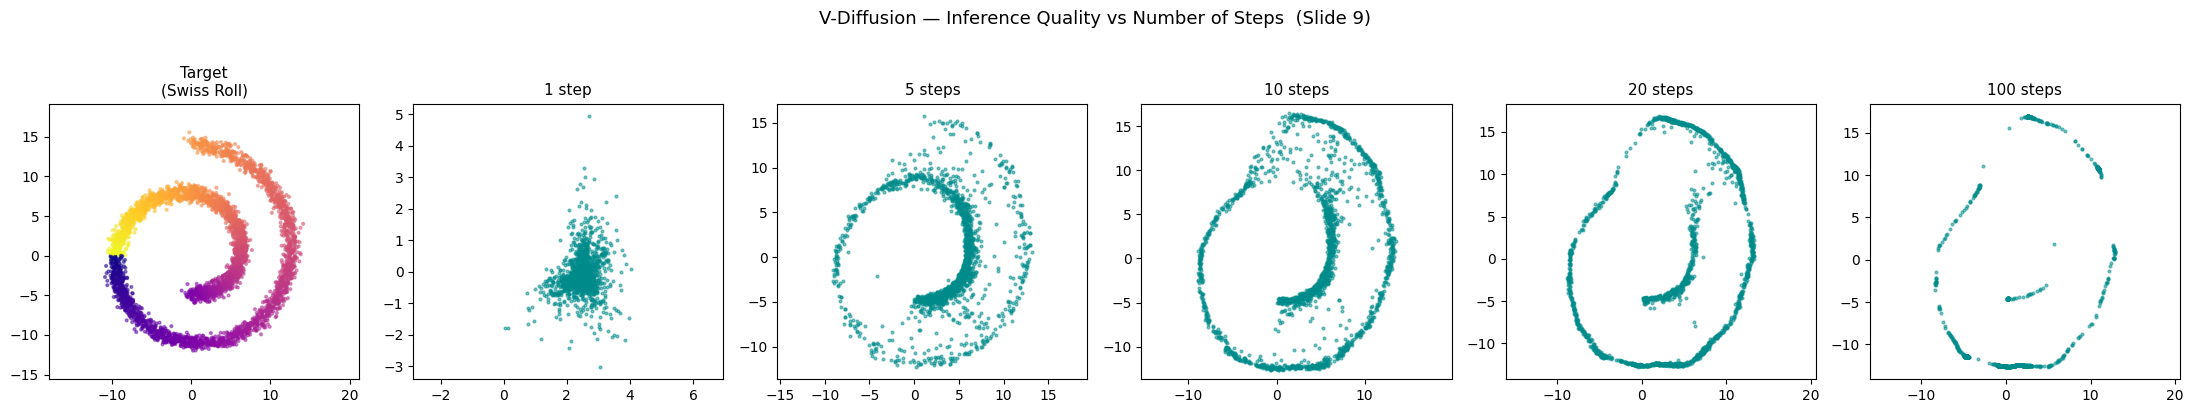

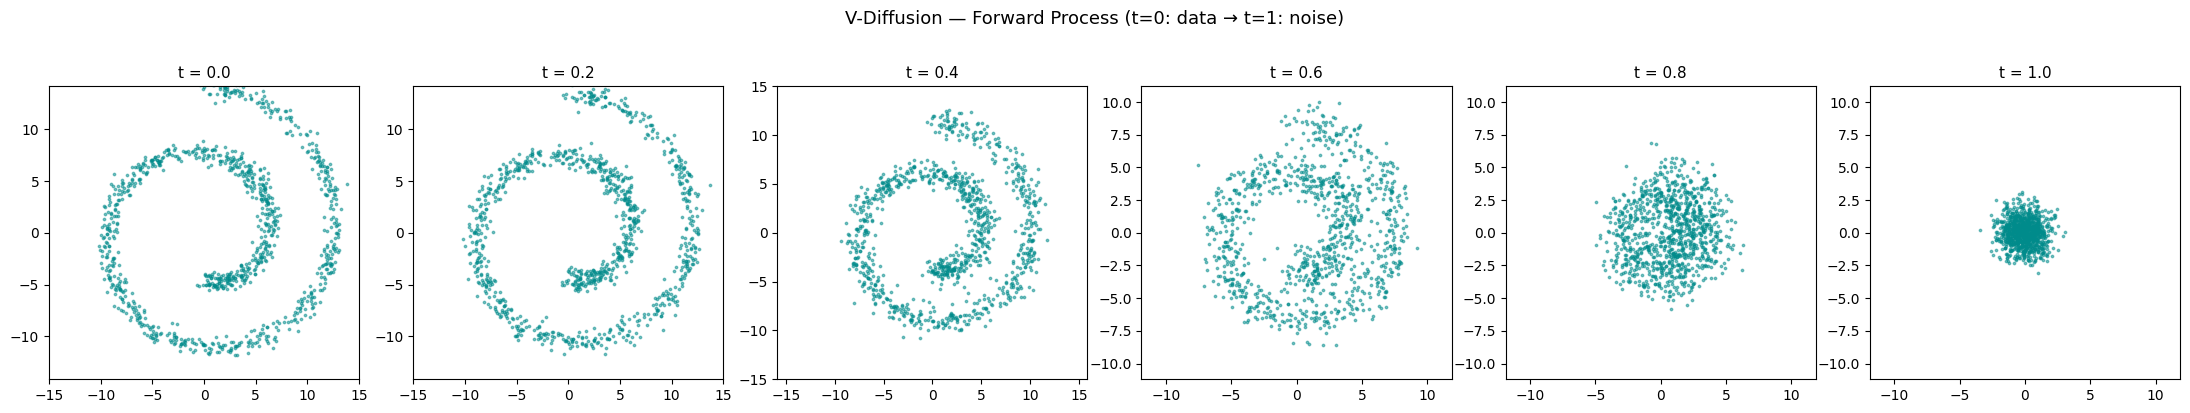


Target std:     [6.726 6.887]
Diffusion(20):  [ 5.939 10.413]
Diffusion(100): [ 4.578 13.305]


In [90]:
# ── Plots ──────────────────────────────────────────────────────────────────────

# Fig 1: Training loss
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='darkcyan', lw=1.0, alpha=0.6)
w = 50
plt.plot(np.convolve(loss_history, np.ones(w)/w, 'valid'), color='darkcyan', lw=2.0, label='MSE (smoothed)')
plt.title('V-Diffusion — Training Loss'); plt.xlabel('Step'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Fig 2: Slide 9 — 1 / 5 / 10 / 20 / 100 steps
fig, axes = plt.subplots(1, len(steps_to_try) + 1, figsize=(22, 4))

axes[0].scatter(target_samples[:,0], target_samples[:,1], s=4, alpha=0.5,
                c=np.arctan2(target_samples[:,1], target_samples[:,0]), cmap='plasma')
axes[0].set_title('Target\n(Swiss Roll)', fontsize=11); axes[0].axis('equal')

for ax, s in zip(axes[1:], steps_to_try):
    ax.scatter(generated[s][:,0], generated[s][:,1], s=4, alpha=0.5, color='darkcyan')
    ax.set_title(f'{s} step{"s" if s > 1 else ""}', fontsize=11)
    ax.axis('equal')

plt.suptitle('V-Diffusion — Inference Quality vs Number of Steps  (Slide 9)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Fig 3: Forward process visualised
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
x0_vis = swissRoll(1024).numpy()
t_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
for ax, t_val in zip(axes, t_vals):
    x_t, _ = v_forward(tf.constant(x0_vis, dtype=tf.float32),
                        tf.fill((1024, 1), tf.cast(t_val, tf.float32)))
    ax.scatter(x_t.numpy()[:,0], x_t.numpy()[:,1], s=3, alpha=0.5, color='darkcyan')
    ax.set_title(f't = {t_val}', fontsize=11); ax.axis('equal')
    ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.suptitle('V-Diffusion — Forward Process (t=0: data → t=1: noise)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Stats
diff_20 = generated[20]
print(f'\nTarget std:     {target_samples.std(axis=0).round(3)}')
print(f'Diffusion(20):  {diff_20.std(axis=0).round(3)}')
print(f'Diffusion(100): {generated[100].std(axis=0).round(3)}')
